In [3]:
import pickle
import pandas as pd
import numpy as np
import gc

## RF

In [4]:
filepath_base_rf = "model/credit/base_rf_ros_38_feats_20250702.pkl"
with open(filepath_base_rf, "rb") as f:
    base_rf = pickle.load(f)

## Data

In [5]:
df_final = pd.read_parquet("data/ready_to_train/df_credit_final_21_feats_20250702.parquet")

In [6]:
# setup pipeline
from src.model_pipeline import ModelPipeline

pipeline_rf = ModelPipeline(model_type="random_forest", random_state=42)

split_date = '2025-05-01'
df_splits = pipeline_rf.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 1197282, Test samples: 201546
Data splitting complete.


In [7]:
# prepare OOS data
target_col = "Confirmed"
X, y = pipeline_rf.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'CustomerSex': ['0', '1', '2', '__missing__']
  Fitted categories for column 'MCCCategory': ['AIRLINES, AIR CARRIERS', 'ASSOCIATIONS/ORGANIZATIONS', 'BUSINESS/PROFESSIONAL/MISCELLANEOUS SERVICES', 'CAR RENTAL AGENCIES', 'CLOTHING/SHOES/ACCESSORIES/UNIFORMS/RETAIL STORES/BUYING AND SELLING SERVICES', 'EDUCATIONAL SERVICES', 'ELECTRONIC AND TECHNICAL SERVICES', 'ENTERTAINMENT/THEATER/DANCE STUDIOS', 'FINANCIAL SERVICES', 'FURNISHINGS/APPLIANCES/MAINTENANCE/HOME', 'GROCERY STORES/PHARMACIES/FOOD SERVICES/RESTAURANTS', 'HEALTHCARE/CHILD SERVICES', 'LODGING — HOTELS, MOTELS, RESORTS', 'OTHER', 'PERSONAL SERVICES', 'TRAVEL/TRANSPORTATION/GAS AND FUEL SERVICES', '__missing__']
CategoryManager fitting complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying

In [15]:
X_oos, y_oos = pipeline_rf.prepare_data(
    df=df_splits["df_test"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['CustomerSex', 'MCCCategory'], dtype='object')...
Identified numerical columns for imputation: ['AvgTimeFirstTxnToCurrentMCCL30D', 'TxnCountToPOSModeL15min', 'RatioTxnCountToPOSModeL30DL15min', 'CntUniqueCardNoByCurrencyCodeL30D', 'RatioTxnCountL30DL15min', 'RatioCntUniqueCardNoByCurrencyCodeL30DL15min', 'TransactionAmount', 'CntUniqueMCCByCardNoL15min', 'TxnTimeDifference', 'RatioCntUniqueMCCByCardNoL30DL15min', 'TxnCountL15min', 'RatioTxnCountToCountryCodeL30DL15min', 'RatioTxnCountToMCCL30DL15min', 'RatioSumAmtToMCCL30DL15min', 'TxnCountToCountryCodeL15min', 'MaxAmtToMCCL30D', 'AvgTimeFirstTxnToCurrentMCCL15min', 'TotalTrxAmount10Mi', 'IsTop10HighRiskMCCLast30D']
Identified categorical columns (encoded): []
Transforming 

In [40]:
X_oos.columns

Index(['AvgTimeFirstTxnToCurrentMCCL30D', 'TxnCountToPOSModeL15min',
       'RatioTxnCountToPOSModeL30DL15min', 'CntUniqueCardNoByCurrencyCodeL30D',
       'RatioTxnCountL30DL15min',
       'RatioCntUniqueCardNoByCurrencyCodeL30DL15min', 'TransactionAmount',
       'CntUniqueMCCByCardNoL15min', 'TxnTimeDifference',
       'RatioCntUniqueMCCByCardNoL30DL15min', 'TxnCountL15min',
       'RatioTxnCountToCountryCodeL30DL15min', 'RatioTxnCountToMCCL30DL15min',
       'RatioSumAmtToMCCL30DL15min', 'TxnCountToCountryCodeL15min',
       'MaxAmtToMCCL30D', 'AvgTimeFirstTxnToCurrentMCCL15min',
       'TotalTrxAmount10Mi', 'IsTop10HighRiskMCCLast30D', 'CustomerSex_1',
       'CustomerSex_2', 'CustomerSex___missing__',
       'MCCCategory_ASSOCIATIONS/ORGANIZATIONS',
       'MCCCategory_BUSINESS/PROFESSIONAL/MISCELLANEOUS SERVICES',
       'MCCCategory_CAR RENTAL AGENCIES',
       'MCCCategory_CLOTHING/SHOES/ACCESSORIES/UNIFORMS/RETAIL STORES/BUYING AND SELLING SERVICES',
       'MCCCategory_EDUCA

# Binning Proba Analysis

In [8]:
from src.utils import plot_confusion_matrix, generate_pred_df, compute_bin_aggregates

In [9]:
df_pred = generate_pred_df(
    X=X_oos,
    y=y_oos,
    clf=base_rf,
    amount_col='TransactionAmount',
    bin_on='pbad',
    increment_bin_rate=0.025,
    bins=None
)

In [10]:
df_agg = compute_bin_aggregates(df_pred)

C:\Users\Administrator\BDI-predator\ml-fraud\src\utils.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = pred_df.groupby("bin").agg(agg_cols)


In [11]:
df_agg.to_csv("data/result/credit_rf_bin_proba_analysis_20250702.csv")

In [12]:
df_agg[["total_trnx_amt", "cum_bad_rate", "cum_good_rate", "cum_records_passed", "cum_records_rejected", "pass_through_rate"]]

,total_trnx_amt,cum_bad_rate,cum_good_rate,cum_records_passed,cum_records_rejected,pass_through_rate
bin,,,,,,
"[0.0, 0.025)",2.024242e+11,0.007403,0.992597,201546,145997,1.000000
"[0.025, 0.05)",5.792455e+10,0.026661,0.973339,55549,170715,0.275614
"[0.05, 0.075)",1.778302e+10,0.047128,0.952872,30831,178274,0.152973
"[0.075, 0.1)",1.421309e+10,0.061404,0.938596,23272,182792,0.115467
"[0.1, 0.125)",1.110225e+10,0.075184,0.924816,18754,185644,0.093051
"[0.125, 0.15)",7.789358e+09,0.087222,0.912778,15902,187810,0.078900
"[0.15, 0.175)",7.664394e+09,0.099520,0.900480,13736,189641,0.068153
"[0.175, 0.2)",4.977359e+09,0.113902,0.886098,11905,191099,0.059068
"[0.2, 0.225)",3.514862e+09,0.127309,0.872691,10447,192362,0.051834


In [15]:
y_oos_prob = base_rf.predict_proba(X_oos)[:, 1]

In [18]:
df_pred = X_oos.join(y_oos)
df_pred = df_pred[['Confirmed']]

In [21]:
df_pred['P_Bad'] = y_oos_prob
df_pred['Confirmed'] = df_pred['Confirmed'].astype(int)

In [23]:
df_pred.to_csv("data/result/CREDIT_df_pred_oos_rf_20250703.csv")

# Feature Importance

In [9]:
df_importance = pd.DataFrame(
    {"feature": X.columns, "importance": base_rf.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

In [54]:
df_importance

,feature,importance
0,AvgTimeFirstTxnToCurrentMCCL30D,0.109830
1,CntUniqueCardNoByCurrencyCodeL30D,0.086648
2,TxnCountToPOSModeL15min,0.086007
3,RatioTxnCountToPOSModeL30DL15min,0.082860
4,MCCCategory_BUSINESS/PROFESSIONAL/MISCELLANEOU...,0.080917
5,TransactionAmount,0.063703
6,TxnTimeDifference,0.054247
7,RatioCntUniqueCardNoByCurrencyCodeL30DL15min,0.045411
8,RatioTxnCountL30DL15min,0.040509
9,TotalTrxAmount10Mi,0.036782


In [21]:
df_importance.to_csv("data/result/credit_rf_importance_20250624.csv", index=False)

# False Positive Reduction

In [10]:
from src.utils import plot_confusion_matrix

In [11]:
df_cc_rules = pd.read_parquet("data/others/credit_card_triggered_rules.parquet")

In [22]:
df_cc_rules_join = df_cc_rules.merge(X_oos['TransactionAmount'], how='left', left_on='Transaction Serial No', right_index=True)

In [31]:
# fraud rules
print("actual fraud amount from Rules that prevented:", 
      df_cc_rules_join[(df_cc_rules_join['IsTriggeredRules'] == 1) & (df_cc_rules_join['Confirmed'] == 1)]['TransactionAmount'].sum())
print("false positive amount from Rules that loss:",
      df_cc_rules_join[(df_cc_rules_join['IsTriggeredRules'] == 1) & (df_cc_rules_join['Confirmed'] == 0)]['TransactionAmount'].sum())

actual fraud amount from Rules that prevented: 2513902748.56
false positive amount from Rules that loss: 11824628594.77


In [16]:
X_oos_selected = X_oos[X_oos.index.isin(df_cc_rules['Transaction Serial No'])]
y_oos_selected = y_oos[y_oos.index.isin(df_cc_rules['Transaction Serial No'])]

In [17]:
y_oos_proba_selected = base_rf.predict_proba(X_oos_selected)[:, 1]

In [37]:
df_oos_selected = X_oos_selected[['TransactionAmount']].join(y_oos_selected).copy()
df_oos_selected['MLScore'] = y_oos_proba_selected

In [39]:
# ML
print("actual fraud amount from Rules that prevented:", 
      df_oos_selected[(df_oos_selected['MLScore'] > 0.445) & (df_oos_selected['Confirmed'] == 1)]['TransactionAmount'].sum())
print("false positive amount from Rules that loss:",
      df_oos_selected[(df_oos_selected['MLScore'] > 0.445) & (df_oos_selected['Confirmed'] == 0)]['TransactionAmount'].sum())

actual fraud amount from Rules that prevented: 2658804092.93
false positive amount from Rules that loss: 5114321836.1


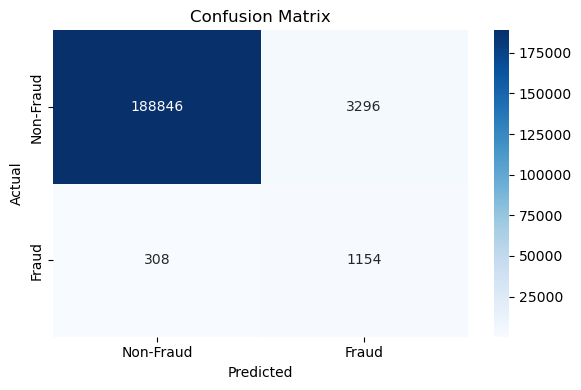

Recall/True Positive Rate: The model got 78.93% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 25.93% of correctly predicted fraud from all transactions that predicted as fraud
Alert Rate: The model will bring 2.3% of the records from total to the Alert rate


In [29]:
threshold_oos = 0.445
plot_confusion_matrix(y_oos_selected, y_oos_proba_selected, threshold_oos)

In [50]:
df_pred_selected = generate_pred_df(
    X=X_oos_selected,
    y=y_oos_selected,
    clf=base_rf,
    amount_col='TransactionAmount',
    bin_on='pbad',
    increment_bin_rate=0.025,
    bins=None
)

In [51]:
df_agg_selected = compute_bin_aggregates(df_pred_selected)

C:\Users\Administrator\BDI-predator\ml-fraud\src\utils.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = pred_df.groupby("bin").agg(agg_cols)


In [52]:
df_agg_selected.to_csv("data/result/credit_rf_bin_proba_analysis_20250708.csv")

In [59]:
X_oos_selected['Proba'] = y_oos_proba_selected

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_12052\3018309234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_oos_selected['Proba'] = y_oos_proba_selected


In [61]:
merged_df = pd.merge(
    df_cc_rules[[
        'Transaction Serial No',
        'Transaction Datetime',
        'Triggered_Rules',
        'Channel',
        'Confirmed',
        'IsTriggeredRules'
    ]],
    X_oos_selected['Proba'],
    left_on='Transaction Serial No',
    right_index=True
)

In [63]:
merged_df.to_csv("data/others/credit_card_rules_ml_20250709.csv", index=False)